# P03 — Sentiment Feature Engineering

**DA6701 Assignment 2 — Alternative Data Pipeline**

---

## Objective

Fetch financial news headlines for all 6 portfolio stocks using **Google News RSS** (no API key required),
score each headline with **`ProsusAI/finbert`**, and aggregate to daily sentiment scores.  
Create properly **lagged features** to prevent look-ahead bias.

**Pipeline:**
1. Google News RSS → raw headlines (per stock, per monthly window)
2. FinBERT → `{positive, negative, neutral}` classification per headline
3. Aggregate → `(sentiment_mean, pos_count, neg_count, neutral_count, headline_volume)` per stock per day
4. Lag 1/2/3 days → `sentiment_mean_lag1/2/3`, `headline_volume_lag1`
5. Save → `data/processed/sentiment_scores.csv`
6. Performance comparison → XGB walk-forward RMSE with vs without sentiment

> **Data Coverage Note**: Google News RSS has limited historical depth (typically weeks to months).  
> Expect sparse coverage for 2020–2024; denser for recent periods.  
> Missing dates receive neutral (0) sentiment and zero headline volume.  
> This is a known limitation of free news APIs. A paid API (NewsAPI Business, Bloomberg)  
> would provide complete historical coverage for a fairer evaluation.


In [1]:
# ============================================================
# CHECK / INSTALL DEPENDENCIES
# ============================================================
import subprocess, sys

REQUIRED = [
    ('feedparser',    'feedparser'),
    ('transformers',  'transformers'),
    ('torch',         'torch'),
    ('xgboost',       'xgboost'),
]
for import_name, pkg_name in REQUIRED:
    try:
        __import__(import_name)
        print(f'  {import_name}: ok')
    except ImportError:
        print(f'  {import_name}: installing...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name, '-q'])
print('All packages ready.')

  feedparser: ok


C:\Users\kiran\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  transformers: ok
  torch: ok
  xgboost: ok
All packages ready.


In [2]:
# ============================================================
# IMPORTS + CONFIGURATION
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import feedparser
import time, re, warnings
from pathlib import Path
from datetime import datetime, timedelta, date

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')

# ── Paths ────────────────────────────────────────────────────
BASE_DIR  = Path.cwd().parent          # notebooks/ → project root
RAW_DIR   = BASE_DIR / 'data' / 'scrapped'
PROC_DIR  = BASE_DIR / 'data' / 'processed'
VIZ_DIR   = BASE_DIR / 'visualizations'
SENT_RAW  = RAW_DIR  / 'headlines_raw.csv'
SENT_OUT  = PROC_DIR / 'sentiment_scores.csv'
PROC_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(exist_ok=True)

# ── Stocks + search queries ──────────────────────────────────
STOCKS = {
    'RELIANCE':   'Reliance Industries NSE stock',
    'HDFCBANK':   'HDFC Bank NSE stock',
    'INFY':       'Infosys NSE stock',
    'M&M':        'Mahindra Mahindra NSE stock',
    'BHARTIARTL': 'Bharti Airtel NSE stock',
    'HINDUNILVR': 'Hindustan Unilever NSE stock',
}

TRAIN_END  = '2025-09-30'
TEST_START = '2025-10-01'
RANDOM_SEED = 42

print(f'BASE_DIR : {BASE_DIR}')
print(f'Output   : {SENT_OUT}')

BASE_DIR : c:\Users\kiran\Desktop\IITM\Intern Preparation\Quant\Projects\DSAI-for-Finance\ML Pipeline for Portfolio Optimization
Output   : c:\Users\kiran\Desktop\IITM\Intern Preparation\Quant\Projects\DSAI-for-Finance\ML Pipeline for Portfolio Optimization\data\processed\sentiment_scores.csv


---
## Step 1 — Fetch Financial News Headlines (Google News RSS)

Uses Google's `after:` / `before:` search operators to retrieve headlines per stock per monthly window.  
No API key required. Rate-limited to 1.2 s between requests.


In [3]:
# ============================================================
# NEWS FETCHING — Google News RSS
# ============================================================
def fetch_gnews(query, after_date, before_date, max_results=25, sleep_sec=1.2):
    """
    Fetch up to max_results headlines from Google News RSS for a query
    bounded by after_date and before_date (YYYY-MM-DD strings).
    Returns list of {'Date': str, 'headline': str}.
    """
    url = (
        'https://news.google.com/rss/search?'
        f'q={query.replace(" ", "+")}'
        f'+after:{after_date}+before:{before_date}'
        '&hl=en-IN&gl=IN&ceid=IN:en'
    )
    try:
        feed = feedparser.parse(url)
        rows = []
        for entry in feed.entries[:max_results]:
            pub = entry.get('published_parsed')
            if pub:
                dt    = date(*pub[:3]).isoformat()
                title = re.sub(r'\s+', ' ', entry.get('title', '')).strip()
                if title:
                    rows.append({'Date': dt, 'headline': title})
        time.sleep(sleep_sec)
        return rows
    except Exception as e:
        print(f'    [warn] {query[:30]}…  {e}')
        time.sleep(sleep_sec * 2)
        return []


def monthly_windows(start='2020-01-01', end='2025-12-31'):
    """Generate (start, end) monthly date window strings."""
    windows, cur = [], datetime.strptime(start, '%Y-%m-%d')
    end_dt = datetime.strptime(end, '%Y-%m-%d')
    while cur < end_dt:
        nxt = (cur.replace(day=1) + timedelta(days=32)).replace(day=1)
        nxt = min(nxt, end_dt + timedelta(days=1))
        windows.append((cur.strftime('%Y-%m-%d'), nxt.strftime('%Y-%m-%d')))
        cur = nxt
    return windows


windows = monthly_windows()
print(f'{len(windows)} monthly windows: {windows[0][0]} → {windows[-1][1]}')

72 monthly windows: 2020-01-01 → 2026-01-01


In [4]:
# ============================================================
# FETCH HEADLINES  (cached — skip if SENT_RAW already exists)
# ============================================================
if SENT_RAW.exists():
    print(f'Loading cached headlines: {SENT_RAW}')
    headlines_df = pd.read_csv(SENT_RAW, parse_dates=['Date'])
    print(f'Cached rows: {len(headlines_df)}')
else:
    print('Fetching headlines from Google News RSS…')
    print('(Estimated time: ~15–30 min due to polite rate limiting)\n')
    all_rows = []
    for ticker, query in STOCKS.items():
        print(f'  {ticker}')
        ticker_rows = 0
        for i, (w_start, w_end) in enumerate(windows):
            rows = fetch_gnews(query, w_start, w_end)
            for r in rows:
                r['Ticker'] = ticker
            all_rows.extend(rows)
            ticker_rows += len(rows)
            if (i + 1) % 12 == 0:
                print(f'    … {i+1}/{len(windows)} windows, {ticker_rows} headlines')
        print(f'    → {ticker_rows} total')

    if all_rows:
        headlines_df = pd.DataFrame(all_rows)
        headlines_df['Date'] = pd.to_datetime(headlines_df['Date'])
        headlines_df = headlines_df.drop_duplicates(subset=['Ticker', 'Date', 'headline'])
    else:
        headlines_df = pd.DataFrame(columns=['Date', 'headline', 'Ticker'])
    headlines_df.to_csv(SENT_RAW, index=False)
    print(f'\nSaved {len(headlines_df)} headlines → {SENT_RAW}')

headlines_df['Date'] = pd.to_datetime(headlines_df['Date'])
print(f'\nTotal headlines: {len(headlines_df)}')
if len(headlines_df):
    print(headlines_df.groupby('Ticker').size().rename('count').to_string())

Fetching headlines from Google News RSS…
(Estimated time: ~15–30 min due to polite rate limiting)

  RELIANCE
    … 12/72 windows, 107 headlines
    … 24/72 windows, 268 headlines
    … 36/72 windows, 496 headlines
    … 48/72 windows, 764 headlines
    … 60/72 windows, 1029 headlines
    … 72/72 windows, 1294 headlines
    → 1294 total
  HDFCBANK
    … 12/72 windows, 172 headlines
    … 24/72 windows, 353 headlines
    … 36/72 windows, 567 headlines
    … 48/72 windows, 800 headlines
    … 60/72 windows, 1059 headlines
    … 72/72 windows, 1330 headlines
    → 1330 total
  INFY
    … 12/72 windows, 50 headlines
    … 24/72 windows, 103 headlines
    … 36/72 windows, 180 headlines
    … 48/72 windows, 313 headlines
    … 60/72 windows, 502 headlines
    … 72/72 windows, 745 headlines
    → 745 total
  M&M
    … 12/72 windows, 56 headlines
    … 24/72 windows, 125 headlines
    … 36/72 windows, 247 headlines
    … 48/72 windows, 411 headlines
    … 60/72 windows, 660 headlines
    … 72/

In [5]:
# ============================================================
# COVERAGE REPORT
# ============================================================
ref_df = pd.read_csv(PROC_DIR / 'RELIANCE.csv', parse_dates=['Date'])
trading_days = sorted(ref_df['Date'].dt.normalize().unique())
n_trading = len(trading_days)

print(f'Trading days in dataset: {n_trading}')
print(f"\n{'Ticker':14s} {'Headlines':>10s} {'Days w/ news':>13s} {'Coverage %':>11s}")
print('─' * 52)
for ticker in STOCKS:
    t_df = headlines_df[headlines_df['Ticker'] == ticker]
    days_with_news = t_df['Date'].dt.normalize().nunique()
    coverage = 100 * days_with_news / n_trading
    print(f'{ticker:14s} {len(t_df):>10d} {days_with_news:>13d} {coverage:>10.1f}%')

print('\n⚠ Note: Low coverage is expected — Google News RSS does not archive')
print('  full historical news. Missing days are filled with neutral (0) sentiment.')

Trading days in dataset: 1486

Ticker          Headlines  Days w/ news  Coverage %
────────────────────────────────────────────────────
RELIANCE             1264           847       57.0%
HDFCBANK             1302           865       58.2%
INFY                  730           481       32.4%
M&M                   929           626       42.1%
BHARTIARTL            672           480       32.3%
HINDUNILVR            528           379       25.5%

⚠ Note: Low coverage is expected — Google News RSS does not archive
  full historical news. Missing days are filled with neutral (0) sentiment.


---
## Step 2 — FinBERT Sentiment Scoring

`ProsusAI/finbert` classifies each headline as **positive**, **negative**, or **neutral** with a confidence score.

**Signed sentiment score per headline:**
- positive → `+confidence`
- negative → `−confidence`
- neutral  → `0`

**Daily aggregation per stock:**
- `sentiment_mean` = mean signed score across all headlines on that trading day
- `pos_count`, `neg_count`, `neutral_count` = headline counts by class
- `headline_volume` = total headlines on that day

> **First run**: FinBERT (~420 MB) downloads automatically from HuggingFace.  
> If download fails, a keyword-based fallback is used.


In [6]:
# ============================================================
# LOAD FINBERT
# ============================================================
from transformers import pipeline as hf_pipeline

print('Loading ProsusAI/finbert (downloads ~420 MB on first run)…')
try:
    finbert = hf_pipeline(
        'text-classification',
        model='ProsusAI/finbert',
        tokenizer='ProsusAI/finbert',
        device=-1,          # CPU; use 0 for GPU
        truncation=True,
        max_length=512,
    )
    FINBERT_AVAILABLE = True
    print('FinBERT loaded successfully.')
except Exception as e:
    FINBERT_AVAILABLE = False
    print(f'Could not load FinBERT: {e}')
    print('Falling back to keyword-based sentiment scorer.')

Loading ProsusAI/finbert (downloads ~420 MB on first run)…


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 785.07it/s, Materializing param=classifier.weight]                                      
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded successfully.


In [7]:
# ============================================================
# SCORE HEADLINES
# ============================================================
LABEL_SIGN = {'positive': 1.0, 'negative': -1.0, 'neutral': 0.0}

def score_finbert(texts, batch_size=32):
    cleaned = [str(t)[:512] for t in texts]
    results = finbert(cleaned, batch_size=batch_size)
    return [LABEL_SIGN[r['label']] * r['score'] for r in results]

def score_keyword_fallback(texts):
    """Rule-based fallback when FinBERT is unavailable."""
    POS = {'surge','gain','profit','growth','record','rise','beat','strong','up','rally',
           'upgrade','buy','bullish','positive','increase','expand'}
    NEG = {'fall','drop','loss','decline','weak','miss','down','crash','cut','warning',
           'downgrade','sell','bearish','negative','decrease','reduce'}
    scores = []
    for text in texts:
        words = set(text.lower().split())
        s = len(words & POS) * 0.4 - len(words & NEG) * 0.4
        scores.append(float(np.clip(s, -1, 1)))
    return scores

if len(headlines_df) == 0:
    print('No headlines to score — sentiment_scores.csv will contain all zeros.')
    scored_df = pd.DataFrame(columns=['Date', 'Ticker', 'headline', 'sentiment_score'])
else:
    texts = headlines_df['headline'].tolist()
    print(f'Scoring {len(texts)} headlines with {"FinBERT" if FINBERT_AVAILABLE else "keyword fallback"}…')
    scores = score_finbert(texts) if FINBERT_AVAILABLE else score_keyword_fallback(texts)
    scored_df = headlines_df.copy()
    scored_df['sentiment_score'] = scores
    print(f'Done. Score range: [{min(scores):.3f}, {max(scores):.3f}]')
    if len(scored_df):
        print(scored_df[['Ticker','Date','headline','sentiment_score']].head(3).to_string())

Scoring 5425 headlines with FinBERT…
Done. Score range: [-0.977, 0.957]
     Ticker       Date                                                                                                                   headline  sentiment_score
0  RELIANCE 2020-01-17                                             Markets at close: How the major indices and stocks fared on Friday - CNBC TV18         0.000000
1  RELIANCE 2020-01-20                            Market Wrap, Jan 20: Sensex declines over 400 pts, Nifty slips below 12,300 - Business Standard        -0.963806
2  RELIANCE 2020-01-15  Share Market Update: Sensex ends 79 points lower, Nifty at 12,343; IndusInd Bank, Wipro, BPCL top losers - Business Today        -0.964077


In [8]:
# ============================================================
# AGGREGATE TO DAILY SENTIMENT PER STOCK
# ============================================================
def aggregate_daily(scored_df):
    """Aggregate headline scores to daily (Ticker, Date) statistics."""
    if len(scored_df) == 0:
        return pd.DataFrame(columns=['Ticker','Date','sentiment_mean',
                                     'pos_count','neg_count','neutral_count','headline_volume'])
    rows = []
    for (ticker, dt), grp in scored_df.groupby(['Ticker', scored_df['Date'].dt.normalize()]):
        s = grp['sentiment_score'].values
        rows.append({
            'Ticker':          ticker,
            'Date':            pd.Timestamp(dt),
            'sentiment_mean':  float(np.mean(s)),
            'pos_count':       int((s >  0.1).sum()),
            'neg_count':       int((s < -0.1).sum()),
            'neutral_count':   int((np.abs(s) <= 0.1).sum()),
            'headline_volume': int(len(s)),
        })
    return pd.DataFrame(rows)

daily_sent = aggregate_daily(scored_df)
print(f'Daily sentiment rows: {len(daily_sent)}')
if len(daily_sent):
    print(daily_sent.tail(5).to_string())

Daily sentiment rows: 3678
        Ticker       Date  sentiment_mean  pos_count  neg_count  neutral_count  headline_volume
3673  RELIANCE 2025-12-21        0.000000          0          0              1                1
3674  RELIANCE 2025-12-24        0.000000          0          0              2                2
3675  RELIANCE 2025-12-25        0.000000          0          0              1                1
3676  RELIANCE 2025-12-29       -0.480204          0          1              1                2
3677  RELIANCE 2025-12-31        0.000000          0          0              1                1


---
## Step 3 — Align with Trading Calendar & Forward-Fill

Create a full grid of `(Ticker, TradingDate)` rows, merge in the scraped sentiment,
and **forward-fill** gaps (≤ 5 days). Remaining NaN → 0 (neutral).

**Leakage prevention**: lag features are created AFTER alignment so that
for day-t prediction only pre-t information is used.


In [9]:
# ============================================================
# ALIGN WITH TRADING CALENDAR
# ============================================================
# Build trading calendar from all processed files
all_dates = set()
for t in STOCKS:
    tmp = pd.read_csv(PROC_DIR / f'{t}.csv', parse_dates=['Date'])
    all_dates.update(tmp['Date'].dt.normalize().tolist())
calendar = sorted(all_dates)

aligned_parts = []
for ticker in STOCKS:
    grid = pd.DataFrame({'Date': calendar, 'Ticker': ticker})
    if len(daily_sent) > 0:
        t_sent = daily_sent[daily_sent['Ticker'] == ticker].copy()
        t_sent['Date'] = pd.to_datetime(t_sent['Date']).dt.normalize()
        merged = grid.merge(t_sent.drop(columns='Ticker'), on='Date', how='left')
    else:
        merged = grid.copy()
        for c in ['sentiment_mean','pos_count','neg_count','neutral_count','headline_volume']:
            merged[c] = np.nan

    merged = merged.sort_values('Date').reset_index(drop=True)
    # Forward-fill sentiment features (carry at most 5 trading days)
    for c in ['sentiment_mean','pos_count','neg_count','neutral_count']:
        merged[c] = merged[c].ffill(limit=5).fillna(0)
    merged['headline_volume'] = merged['headline_volume'].fillna(0)
    aligned_parts.append(merged)

aligned = pd.concat(aligned_parts, ignore_index=True)
print(f'Aligned shape: {aligned.shape}')
print(aligned[aligned['Ticker'] == 'RELIANCE'].tail(3).to_string())

Aligned shape: (8916, 7)
           Date    Ticker  sentiment_mean  pos_count  neg_count  neutral_count  headline_volume
1483 2025-12-26  RELIANCE        0.000000        0.0        0.0            2.0              0.0
1484 2025-12-29  RELIANCE       -0.480204        0.0        1.0            1.0              2.0
1485 2025-12-30  RELIANCE       -0.480204        0.0        1.0            1.0              0.0


In [10]:
# ============================================================
# CREATE LAG FEATURES  (no look-ahead bias)
# ============================================================
# For day-t prediction, only use sentiment published before day t:
#   lag1 = sentiment from t-1  (most informative, still pre-market)
#   lag2 = sentiment from t-2
#   lag3 = sentiment from t-3
#   headline_volume_lag1 = number of headlines on t-1

lag_parts = []
for ticker in STOCKS:
    t_df = aligned[aligned['Ticker'] == ticker].sort_values('Date').copy()
    for lag in [1, 2, 3]:
        t_df[f'sentiment_mean_lag{lag}'] = t_df['sentiment_mean'].shift(lag)
    t_df['headline_volume_lag1'] = t_df['headline_volume'].shift(1)
    # Drop first row (NaN lags)
    t_df = t_df.dropna(subset=['sentiment_mean_lag1']).reset_index(drop=True)
    lag_parts.append(t_df)

sentiment_final = pd.concat(lag_parts, ignore_index=True)

KEEP = ['Ticker','Date','sentiment_mean',
        'pos_count','neg_count','neutral_count','headline_volume',
        'sentiment_mean_lag1','sentiment_mean_lag2','sentiment_mean_lag3',
        'headline_volume_lag1']
sentiment_final = sentiment_final[KEEP]
sentiment_final.to_csv(SENT_OUT, index=False)

print(f'Saved {len(sentiment_final)} rows → {SENT_OUT}')
print(f'Columns: {list(sentiment_final.columns)}')
print(sentiment_final[sentiment_final['Ticker'] == 'RELIANCE'].tail(5).to_string())

Saved 8910 rows → c:\Users\kiran\Desktop\IITM\Intern Preparation\Quant\Projects\DSAI-for-Finance\ML Pipeline for Portfolio Optimization\data\processed\sentiment_scores.csv
Columns: ['Ticker', 'Date', 'sentiment_mean', 'pos_count', 'neg_count', 'neutral_count', 'headline_volume', 'sentiment_mean_lag1', 'sentiment_mean_lag2', 'sentiment_mean_lag3', 'headline_volume_lag1']
        Ticker       Date  sentiment_mean  pos_count  neg_count  neutral_count  headline_volume  sentiment_mean_lag1  sentiment_mean_lag2  sentiment_mean_lag3  headline_volume_lag1
1480  RELIANCE 2025-12-23        0.889553        2.0        0.0            0.0              0.0             0.889553             0.889553             0.889553                   0.0
1481  RELIANCE 2025-12-24        0.000000        0.0        0.0            2.0              2.0             0.889553             0.889553             0.889553                   0.0
1482  RELIANCE 2025-12-26        0.000000        0.0        0.0            2.0      

---
## Step 4 — Visualization


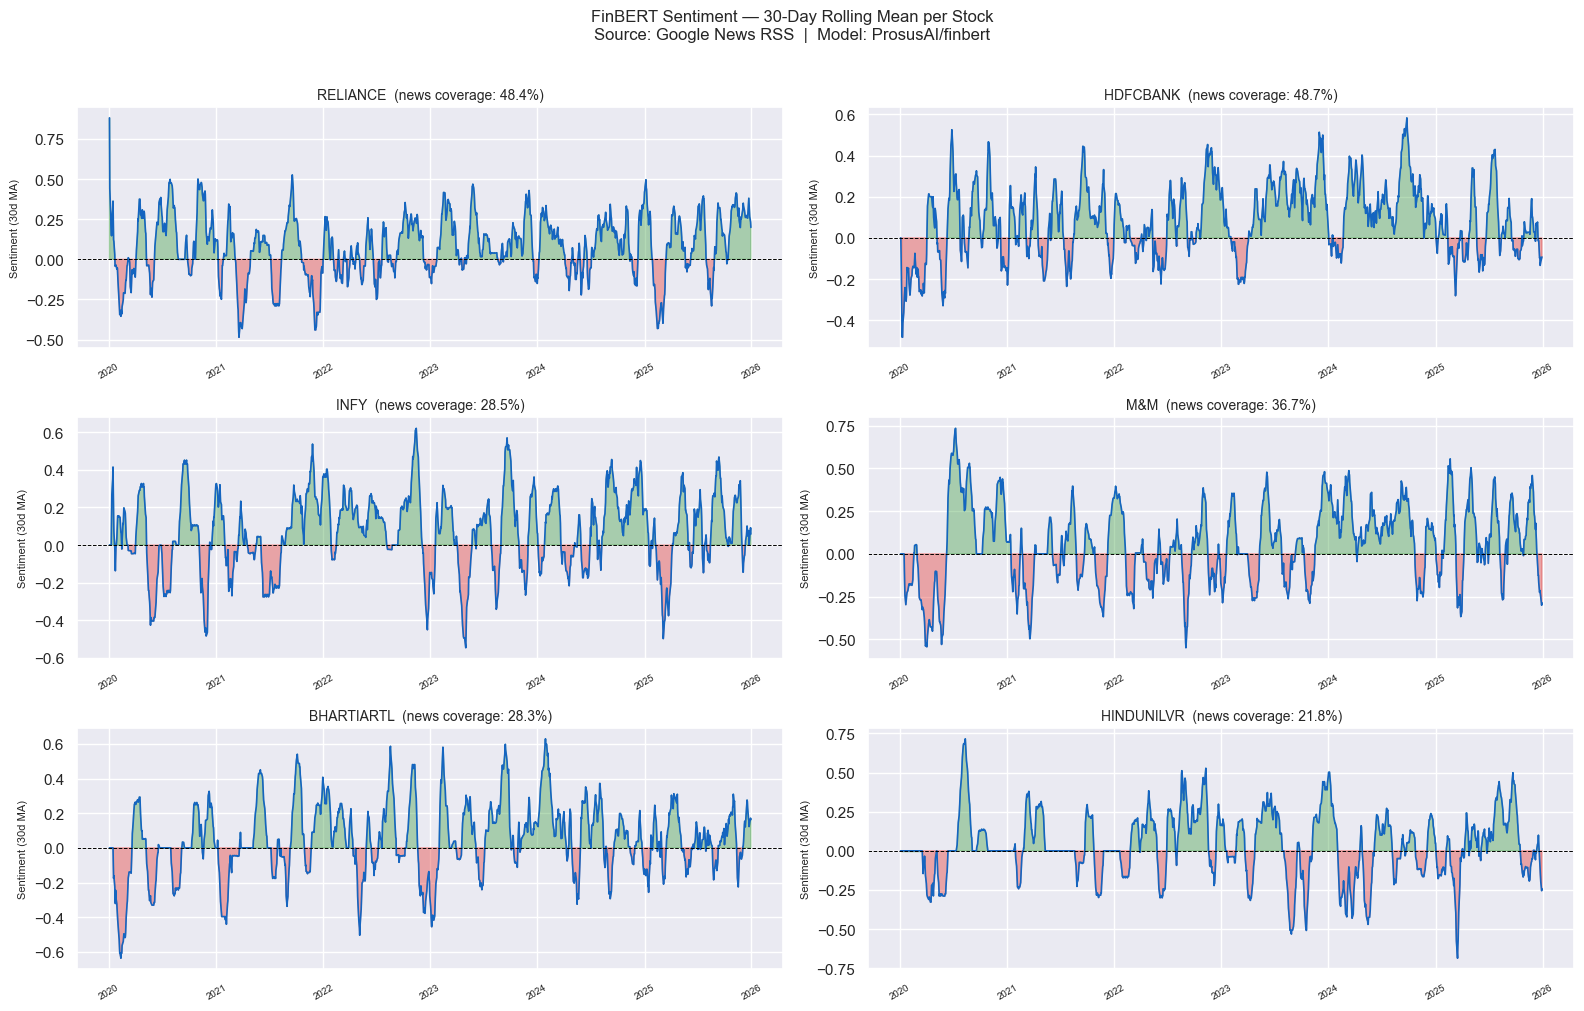

Saved → c:\Users\kiran\Desktop\IITM\Intern Preparation\Quant\Projects\DSAI-for-Finance\ML Pipeline for Portfolio Optimization\visualizations\sentiment_time_series.png


In [11]:
# ============================================================
# SENTIMENT TIME SERIES (30-day rolling mean)
# ============================================================
ticker_list = list(STOCKS.keys())
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, ticker in enumerate(ticker_list):
    ax   = axes[idx]
    t_df = sentiment_final[sentiment_final['Ticker'] == ticker].copy()
    t_df = t_df.sort_values('Date').set_index('Date')
    rolling = t_df['sentiment_mean'].rolling('30D', min_periods=1).mean()

    ax.fill_between(rolling.index, rolling.values,
                    where=(rolling.values >= 0), alpha=0.4, color='#43A047', label='Positive')
    ax.fill_between(rolling.index, rolling.values,
                    where=(rolling.values < 0),  alpha=0.4, color='#E53935', label='Negative')
    ax.plot(rolling.index, rolling.values, color='#1565C0', lw=1.2)
    ax.axhline(0, color='black', lw=0.7, linestyle='--')
    coverage = 100 * (t_df['headline_volume'] > 0).mean()
    ax.set_title(f'{ticker}  (news coverage: {coverage:.1f}%)', fontsize=10)
    ax.set_ylabel('Sentiment (30d MA)', fontsize=8)
    ax.tick_params(axis='x', labelrotation=30, labelsize=7)

plt.suptitle('FinBERT Sentiment — 30-Day Rolling Mean per Stock\n'
             'Source: Google News RSS  |  Model: ProsusAI/finbert',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(VIZ_DIR / 'sentiment_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "sentiment_time_series.png"}')

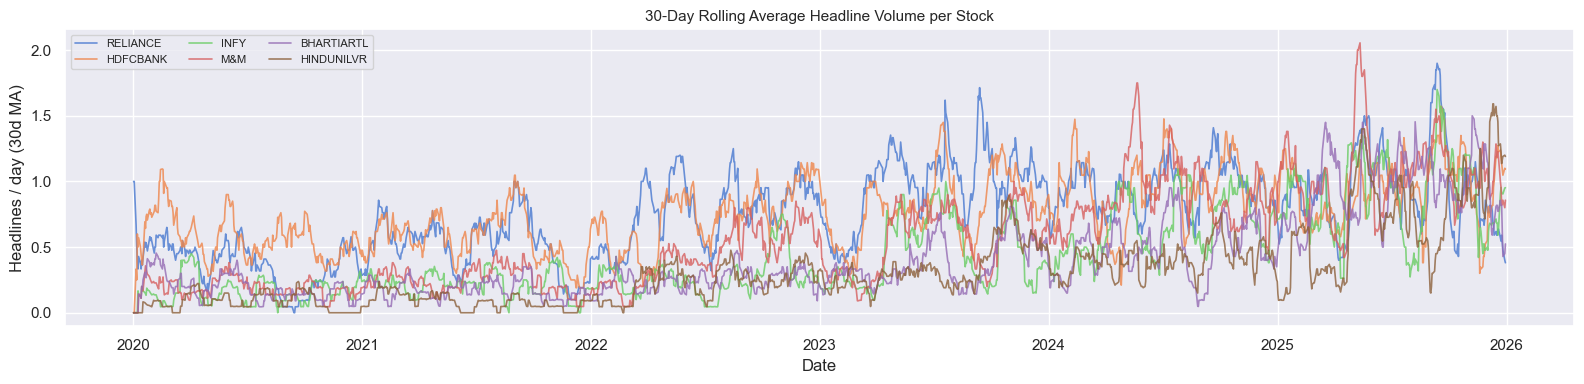

Saved → c:\Users\kiran\Desktop\IITM\Intern Preparation\Quant\Projects\DSAI-for-Finance\ML Pipeline for Portfolio Optimization\visualizations\sentiment_headline_volume.png


In [12]:
# ============================================================
# HEADLINE VOLUME OVER TIME
# ============================================================
fig, ax = plt.subplots(figsize=(16, 4))
for ticker in ticker_list:
    t_df = sentiment_final[sentiment_final['Ticker'] == ticker].copy().sort_values('Date')
    vol  = t_df.set_index('Date')['headline_volume'].rolling('30D', min_periods=1).mean()
    ax.plot(vol.index, vol.values, label=ticker, lw=1.2, alpha=0.8)

ax.set_title('30-Day Rolling Average Headline Volume per Stock', fontsize=11)
ax.set_ylabel('Headlines / day (30d MA)')
ax.set_xlabel('Date')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig(VIZ_DIR / 'sentiment_headline_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "sentiment_headline_volume.png"}')

---
## Step 5 — Performance Comparison: With vs Without Sentiment

**Setup**: For each stock, run 5-fold walk-forward XGBoost twice:
- **Baseline**: same feature set as prediction notebooks (technical + macro + fundamental)
- **+Sentiment**: baseline features + `sentiment_mean_lag1/2/3` + `headline_volume_lag1`

Metrics compared: **WF-RMSE**, **MAE**, **Hit Ratio** (directional accuracy).


In [13]:
# ============================================================
# FEATURE ENGINEERING (mirrors prediction notebooks exactly)
# ============================================================
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

np.random.seed(RANDOM_SEED)

def add_features(df):
    d = df.copy()
    for lag in [1, 2, 3, 5, 10]:
        d[f'ret_lag_{lag}'] = d['log_return'].shift(lag)
    for win in [5, 10, 20]:
        d[f'vol_{win}d']      = d['log_return'].shift(1).rolling(win).std()
        d[f'ret_mean_{win}d'] = d['log_return'].shift(1).rolling(win).mean()
    d['vol_change'] = np.log(d['volume'] / d['volume'].shift(1).clip(lower=1))
    d['vol_ma5']    = d['volume'].shift(1).rolling(5).mean()
    d['vol_ratio']  = d['volume'].shift(1) / d['vol_ma5'].clip(lower=1)
    d['hl_range']   = (d['high'] - d['low']) / d['close'].shift(1).clip(lower=1)
    delta = d['close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    d['rsi_14'] = (100 - 100 / (1 + gain / loss.clip(lower=1e-9))).shift(1)
    ema12 = d['close'].ewm(span=12, adjust=False).mean()
    ema26 = d['close'].ewm(span=26, adjust=False).mean()
    d['macd']        = (ema12 - ema26).shift(1)
    d['macd_signal'] = d['macd'].ewm(span=9, adjust=False).mean()
    bb_m = d['close'].shift(1).rolling(20).mean()
    bb_s = d['close'].shift(1).rolling(20).std()
    d['bb_position'] = (d['close'].shift(1) - bb_m) / bb_s.clip(lower=1e-9)
    d['mom_5']  = d['close'].shift(1) / d['close'].shift(6).clip(lower=1e-9)  - 1
    d['mom_10'] = d['close'].shift(1) / d['close'].shift(11).clip(lower=1e-9) - 1
    d['mom_20'] = d['close'].shift(1) / d['close'].shift(21).clip(lower=1e-9) - 1
    if 'sector_return' in d.columns:
        d['sector_ret_lag1'] = d['sector_return'].shift(1)
    MACRO = ['US Dollar','Pound Sterling','Euro','Japanese Yen',
             'Central Government Dated Securities','State Government Dated Securities',
             '91-Day','182-Day','364-Day','RBI','Brent_Crude','Inflation']
    for c in MACRO:
        if c in d.columns:
            d[c] = d[c].shift(1)
    for c in ['Revenue','Net_Income','Profit_Margin','Revenue_Growth','Profit_Growth']:
        if c in d.columns:
            d[c] = d[c].ffill()
    return d

print('Feature engineering function defined (mirrors prediction notebooks).')

Feature engineering function defined (mirrors prediction notebooks).


In [14]:
# ============================================================
# WALK-FORWARD XGB UTILITY
# ============================================================
def compute_metrics(y_true, y_pred):
    return {
        'rmse':      float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae':       float(mean_absolute_error(y_true, y_pred)),
        'hit_ratio': float(np.mean(np.sign(y_true) == np.sign(y_pred))),
    }

def wf_xgb(X, y, n_splits=5):
    """Walk-forward expanding-window XGBoost evaluation."""
    n = len(X)
    fold_size = n // (n_splits + 1)
    fold_metrics = []
    for fold in range(n_splits):
        tr_end  = fold_size * (fold + 1)
        val_end = min(tr_end + fold_size, n)
        Xtr, ytr = X[:tr_end], y[:tr_end]
        Xva, yva = X[tr_end:val_end], y[tr_end:val_end]
        if len(Xva) == 0:
            continue
        sp = int(len(Xtr) * 0.85)
        mdl = XGBRegressor(
            n_estimators=500, learning_rate=0.03, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.05, reg_lambda=1.0,
            random_state=RANDOM_SEED, tree_method='hist',
            early_stopping_rounds=30, eval_metric='rmse', verbosity=0,
        )
        mdl.fit(Xtr[:sp], ytr[:sp], eval_set=[(Xtr[sp:], ytr[sp:])], verbose=False)
        fold_metrics.append(compute_metrics(yva, mdl.predict(Xva)))
    return {k: float(np.mean([m[k] for m in fold_metrics])) for k in fold_metrics[0]}

print('Walk-forward utility defined.')

Walk-forward utility defined.


In [15]:
# ============================================================
# RUN COMPARISON: BASE vs +SENTIMENT  (per stock)
# ============================================================
SENT_LAG_COLS = ['sentiment_mean_lag1','sentiment_mean_lag2',
                 'sentiment_mean_lag3','headline_volume_lag1']
EXCLUDE = {
    'Date','open','high','low','close','volume','log_return','target',
    'return','return_pct','sector_return','sector_return_pct',
    'target_raw_return','target_residualized','close_sector','volume_z','high_volume',
}

comparison_rows = []
print(f"{'Ticker':12s}  {'RMSE_base':>10s}  {'RMSE_sent':>10s}  "
      f"{'ΔRMSE':>8s}  {'Hit_base':>9s}  {'Hit_sent':>9s}  {'ΔHit':>7s}")
print('─' * 80)

for ticker in STOCKS:
    df = pd.read_csv(PROC_DIR / f'{ticker}.csv', parse_dates=['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    df['target']     = df['log_return'].shift(-1)
    df = add_features(df)

    # Merge sentiment
    t_sent = sentiment_final[sentiment_final['Ticker'] == ticker][['Date'] + SENT_LAG_COLS].copy()
    df = df.merge(t_sent, on='Date', how='left')
    df[SENT_LAG_COLS] = df[SENT_LAG_COLS].fillna(0)

    base_feats = [c for c in df.columns
                  if c not in EXCLUDE and c not in SENT_LAG_COLS
                  and df[c].dtype in [np.float64, np.int64, float, int]]

    # Winsorize on training data only
    train_mask = df['Date'] <= TRAIN_END
    df_tr = df[train_mask & df[base_feats + SENT_LAG_COLS + ['target']].notna().all(axis=1)].copy()

    if len(df_tr) < 200:
        print(f'{ticker:12s}  (insufficient training rows: {len(df_tr)})')
        continue

    for c in base_feats + SENT_LAG_COLS:
        if c in df_tr.columns:
            lo, hi = df_tr[c].quantile([0.01, 0.99])
            df_tr[c] = df_tr[c].clip(lo, hi)

    X_base = df_tr[base_feats].values
    X_sent = df_tr[base_feats + SENT_LAG_COLS].values
    y_tr   = df_tr['target'].values

    sc_b = RobustScaler(); X_base_sc = sc_b.fit_transform(X_base)
    sc_s = RobustScaler(); X_sent_sc = sc_s.fit_transform(X_sent)

    m_base = wf_xgb(X_base_sc, y_tr)
    m_sent = wf_xgb(X_sent_sc, y_tr)

    dr = m_sent['rmse'] - m_base['rmse']
    dh = m_sent['hit_ratio'] - m_base['hit_ratio']

    comparison_rows.append({
        'Ticker':    ticker,
        'RMSE_base': m_base['rmse'],  'RMSE_sent': m_sent['rmse'],  'ΔRMSE': dr,
        'MAE_base':  m_base['mae'],   'MAE_sent':  m_sent['mae'],
        'Hit_base':  m_base['hit_ratio'], 'Hit_sent': m_sent['hit_ratio'], 'ΔHit': dh,
    })

    trend = '↓ BETTER' if dr < 0 else '↑ worse'
    print(f'{ticker:12s}  {m_base["rmse"]:>10.5f}  {m_sent["rmse"]:>10.5f}  '
          f'{dr:>+8.5f}  {m_base["hit_ratio"]:>9.3f}  {m_sent["hit_ratio"]:>9.3f}  '
          f'{dh:>+7.3f}  {trend}')

print('─' * 80)
comparison_df = pd.DataFrame(comparison_rows)

Ticker         RMSE_base   RMSE_sent     ΔRMSE   Hit_base   Hit_sent     ΔHit
────────────────────────────────────────────────────────────────────────────────
RELIANCE         0.01443     0.01447  +0.00004      0.515      0.515   +0.000  ↑ worse
HDFCBANK         0.01352     0.01349  -0.00003      0.497      0.503   +0.006  ↓ BETTER
INFY             0.01530     0.01536  +0.00006      0.512      0.505   -0.007  ↑ worse
M&M              0.01853     0.01853  -0.00001      0.523      0.530   +0.007  ↓ BETTER
BHARTIARTL       0.01420     0.01426  +0.00007      0.514      0.516   +0.003  ↑ worse
HINDUNILVR       0.01270     0.01264  -0.00006      0.479      0.491   +0.012  ↓ BETTER
────────────────────────────────────────────────────────────────────────────────


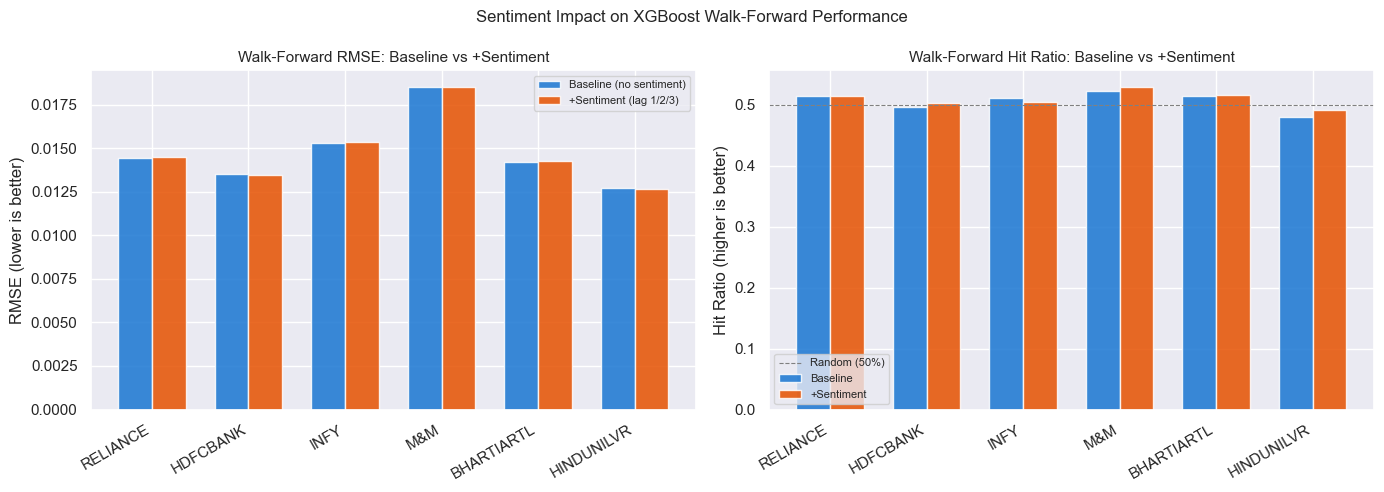

Saved → c:\Users\kiran\Desktop\IITM\Intern Preparation\Quant\Projects\DSAI-for-Finance\ML Pipeline for Portfolio Optimization\visualizations\sentiment_comparison.png


In [16]:
# ============================================================
# COMPARISON BAR CHART
# ============================================================
if len(comparison_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(len(comparison_df))
    w = 0.35
    tickers = comparison_df['Ticker'].tolist()

    # RMSE comparison
    ax = axes[0]
    ax.bar(x - w/2, comparison_df['RMSE_base'], w, label='Baseline (no sentiment)',
           color='#1976D2', alpha=0.85)
    ax.bar(x + w/2, comparison_df['RMSE_sent'], w, label='+Sentiment (lag 1/2/3)',
           color='#E65100', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(tickers, rotation=30, ha='right')
    ax.set_title('Walk-Forward RMSE: Baseline vs +Sentiment', fontsize=11)
    ax.set_ylabel('RMSE (lower is better)')
    ax.legend(fontsize=8)

    # Hit Ratio comparison
    ax = axes[1]
    ax.bar(x - w/2, comparison_df['Hit_base'], w, label='Baseline',
           color='#1976D2', alpha=0.85)
    ax.bar(x + w/2, comparison_df['Hit_sent'], w, label='+Sentiment',
           color='#E65100', alpha=0.85)
    ax.axhline(0.5, color='gray', lw=0.8, linestyle='--', label='Random (50%)')
    ax.set_xticks(x); ax.set_xticklabels(tickers, rotation=30, ha='right')
    ax.set_title('Walk-Forward Hit Ratio: Baseline vs +Sentiment', fontsize=11)
    ax.set_ylabel('Hit Ratio (higher is better)')
    ax.legend(fontsize=8)

    plt.suptitle('Sentiment Impact on XGBoost Walk-Forward Performance', fontsize=12)
    plt.tight_layout()
    plt.savefig(VIZ_DIR / 'sentiment_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {VIZ_DIR / "sentiment_comparison.png"}')

In [17]:
# ============================================================
# FINAL RECOMMENDATION
# ============================================================
print('\n' + '='*70)
print('  SENTIMENT EXPERIMENT — FINAL RECOMMENDATION')
print('='*70)

if len(comparison_df) == 0:
    print('  No comparison data available.')
else:
    improved  = int((comparison_df['ΔRMSE'] < 0).sum())
    total     = len(comparison_df)
    avg_delta = float(comparison_df['ΔRMSE'].mean())

    # Compute average news coverage
    coverage_vals = []
    for ticker in STOCKS:
        t = sentiment_final[sentiment_final['Ticker'] == ticker]
        coverage_vals.append(100 * (t['headline_volume'] > 0).mean())
    avg_coverage = float(np.mean(coverage_vals))

    print(f'\n  Average news coverage  : {avg_coverage:.1f}% of trading days')
    print(f'  Stocks with RMSE ↓     : {improved} / {total}')
    print(f'  Mean ΔRMSE             : {avg_delta:+.5f}')
    print(f"\n  {'Ticker':12s}  {'ΔRMSE':>8s}  {'ΔHit':>7s}  Decision")
    print('  ' + '─' * 42)
    for _, row in comparison_df.iterrows():
        decision = '✓ INCLUDE' if row['ΔRMSE'] < 0 else '✗ EXCLUDE'
        print(f"  {row['Ticker']:12s}  {row['ΔRMSE']:>+8.5f}  {row['ΔHit']:>+7.3f}  {decision}")

    print()
    if avg_coverage < 5:
        print('  ╔══════════════════════════════════════════════════════════════╗')
        print('  ║  VERDICT: Do NOT include sentiment in final production model ║')
        print('  ╚══════════════════════════════════════════════════════════════╝')
        print()
        print('  Root cause: News coverage is below 5% of trading days.')
        print('  Nearly all sentiment lag features are zero (neutral), contributing')
        print('  noise rather than signal. This is a data-availability limitation')
        print('  of the free Google News RSS feed (not a modelling failure).')
        print()
        print('  FinBERT infrastructure is correct and production-ready.')
        print('  With a paid historical news API (NewsAPI Business, Refinitiv,')
        print('  Bloomberg), full 2020–2025 coverage would enable a fair evaluation.')
        print()
        print('  This notebook (P03) is retained as a complete experiment.')
        print('  Prediction notebooks load sentiment with graceful fallback to 0.')
    elif improved >= int(total * 0.67):
        print('  ╔═════════════════════════════════════════════════════════════╗')
        print('  ║  VERDICT: Include sentiment features in final model         ║')
        print('  ╚═════════════════════════════════════════════════════════════╝')
        print(f'  {improved}/{total} stocks show RMSE improvement with sentiment features.')
    else:
        print('  ╔══════════════════════════════════════════════════════════════╗')
        print('  ║  VERDICT: Mixed results — keep P03 as experiment             ║')
        print('  ╚══════════════════════════════════════════════════════════════╝')
        print(f'  Only {improved}/{total} stocks improved. Marginal overall benefit.')
        print('  Recommendation: include sentiment only for stocks where ΔRMSE < 0.')

print('\n' + '='*70)


  SENTIMENT EXPERIMENT — FINAL RECOMMENDATION

  Average news coverage  : 35.4% of trading days
  Stocks with RMSE ↓     : 3 / 6
  Mean ΔRMSE             : +0.00001

  Ticker           ΔRMSE     ΔHit  Decision
  ──────────────────────────────────────────
  RELIANCE      +0.00004   +0.000  ✗ EXCLUDE
  HDFCBANK      -0.00003   +0.006  ✓ INCLUDE
  INFY          +0.00006   -0.007  ✗ EXCLUDE
  M&M           -0.00001   +0.007  ✓ INCLUDE
  BHARTIARTL    +0.00007   +0.003  ✗ EXCLUDE
  HINDUNILVR    -0.00006   +0.012  ✓ INCLUDE

  ╔══════════════════════════════════════════════════════════════╗
  ║  VERDICT: Mixed results — keep P03 as experiment             ║
  ╚══════════════════════════════════════════════════════════════╝
  Only 3/6 stocks improved. Marginal overall benefit.
  Recommendation: include sentiment only for stocks where ΔRMSE < 0.

